# Comparing clustering methods

A [scikit-learn-style](https://scikit-learn.org/stable/modules/clustering.html) comparison of
clustering algorithms across dataset *shapes*, plus performance-scaling plots. betula's heads sit
next to scikit-learn's so you can read off where each is the right tool — and where betula's
memory-bounded CF-tree wins on scale.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import HDBSCAN, Birch
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler

import betula_cluster
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

## Six dataset shapes

Concentric circles, interleaving moons, unequal-variance blobs, anisotropic blobs, plain blobs,
and structureless uniform noise — the standard stress test for cluster shape.

In [2]:
N = 1500
rng = np.random.default_rng(0)
Xa, _ = make_blobs(n_samples=N, random_state=170)
aniso = Xa @ np.array([[0.6, -0.63], [-0.41, 0.8]])
varied, _ = make_blobs(n_samples=N, cluster_std=[1.0, 2.5, 0.5], random_state=170)

DATASETS = [
    ("circles", make_circles(n_samples=N, factor=0.5, noise=0.05, random_state=0)[0], 2),
    ("moons", make_moons(n_samples=N, noise=0.05, random_state=0)[0], 2),
    ("varied", varied, 3),
    ("aniso", aniso, 3),
    ("blobs", make_blobs(n_samples=N, random_state=8)[0], 3),
    ("uniform", rng.random((N, 2)), 3),
]
DATASETS = [(name, StandardScaler().fit_transform(X), k) for name, X, k in DATASETS]


def methods(k):
    """(column title, callable X -> labels) for each algorithm."""
    return [
        ("betula\nk-means", lambda X: betula_cluster.fit_predict(X, k, feature="diagonal", method="kmeans")),
        ("betula\nGMM-full", lambda X: betula_cluster.fit_predict(X, k, feature="diagonal", method="gmm-full")),
        ("betula\nWard", lambda X: betula_cluster.fit_predict(X, k, feature="diagonal", method="ward")),
        ("betula\nHDBSCAN", lambda X: betula_cluster.fit_predict(X, method="hdbscan", min_samples=5, min_cluster_size=30)),
        ("sklearn\nBirch", lambda X: Birch(n_clusters=k).fit_predict(X)),
        ("sklearn\nHDBSCAN", lambda X: HDBSCAN(min_samples=5, min_cluster_size=30).fit_predict(X)),
    ]

## The comparison grid

Each cell is colored by the predicted label (gray = HDBSCAN noise); the number is the fit+predict
time. Convex methods (k-means / GMM / Ward / Birch) cannot split circles or moons — density-based
HDBSCAN can; on blobs they all agree.

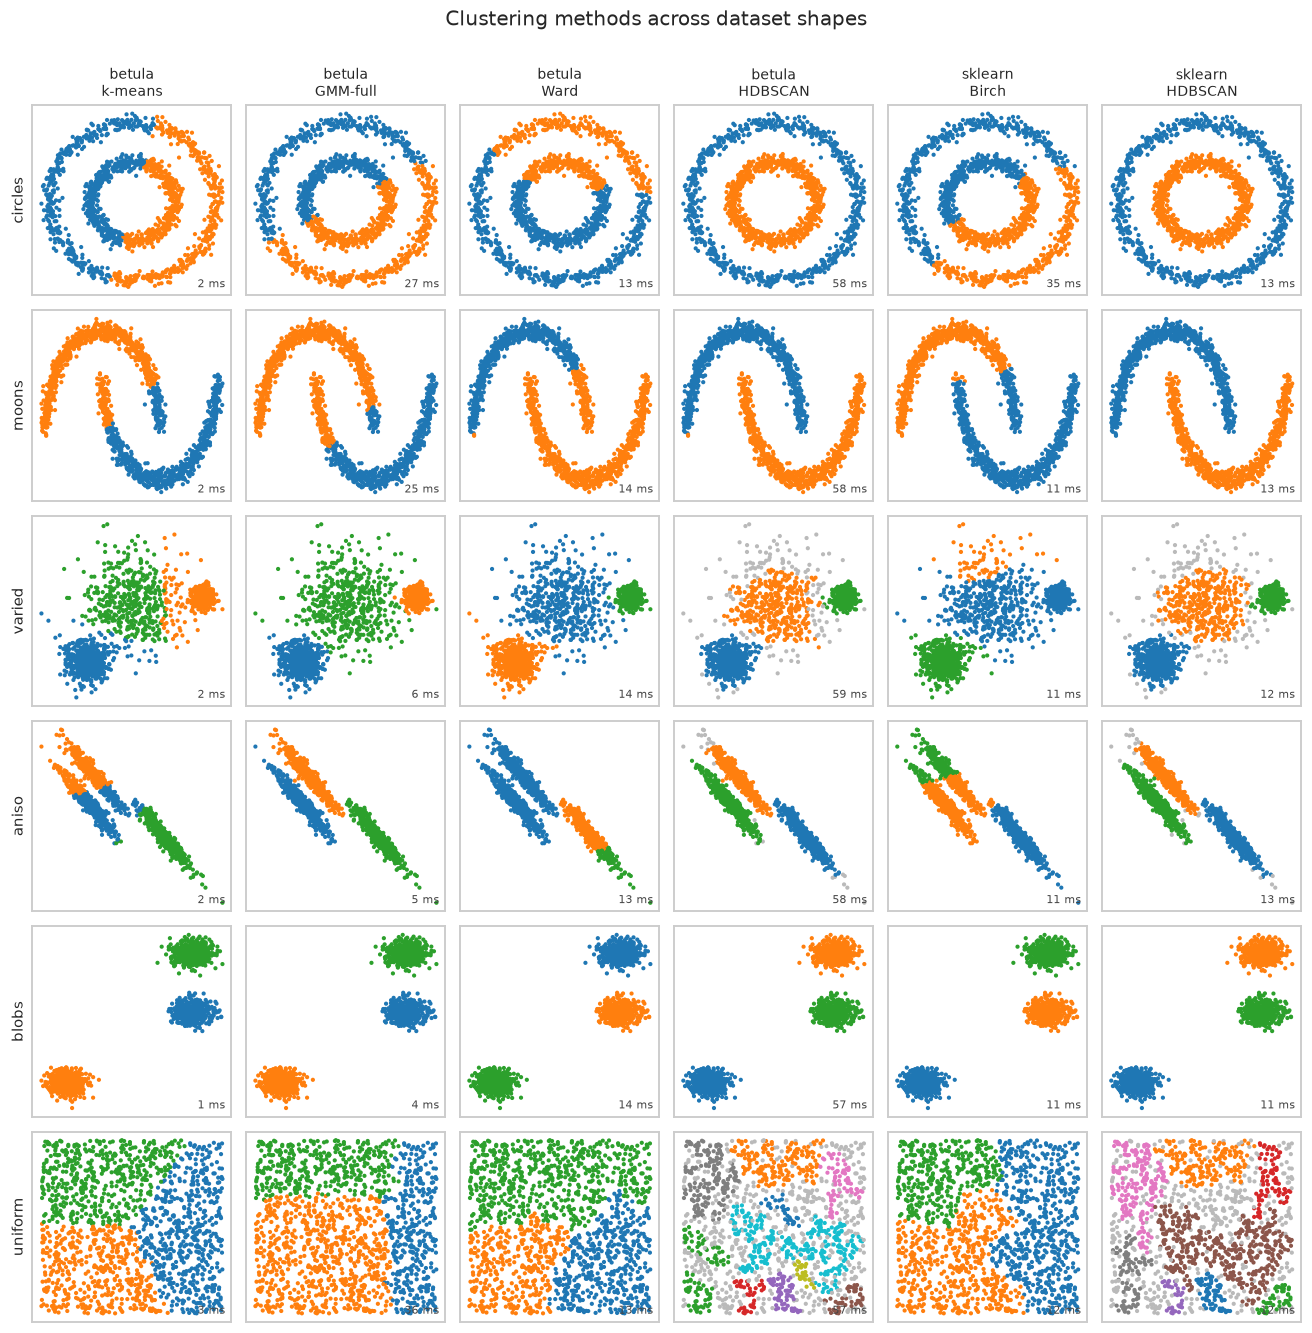

In [3]:
cols = methods(2)
fig, axes = plt.subplots(len(DATASETS), len(cols), figsize=(2.0 * len(cols), 2.0 * len(DATASETS)))

for r, (dname, X, k) in enumerate(DATASETS):
    X = np.ascontiguousarray(X, dtype=np.float64)
    for c, (title, fn) in enumerate(methods(k)):
        ax = axes[r, c]
        t0 = time.perf_counter()
        labels = np.asarray(fn(X))
        dt = time.perf_counter() - t0
        # RGBA per point; HDBSCAN noise (label -1) is drawn gray
        rgba = plt.cm.tab10(np.clip(labels, 0, 9) % 10)
        rgba[labels < 0] = (0.73, 0.73, 0.73, 1.0)
        ax.scatter(X[:, 0], X[:, 1], s=3, c=rgba)
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 0:
            ax.set_title(title, fontsize=9)
        if c == 0:
            ax.set_ylabel(dname, fontsize=10, rotation=90)
        ax.text(0.97, 0.03, f"{dt * 1000:.0f} ms", transform=ax.transAxes, ha="right", va="bottom",
                fontsize=7, color="#444")
fig.suptitle("Clustering methods across dataset shapes", y=1.005, fontsize=13)
fig.tight_layout()
plt.show()

## Performance — time vs N

Two-phase compression keeps betula near-linear and fast; scikit-learn's Birch (whose final
agglomeration is super-linear in the subcluster count) blows up on high-dimensional data.

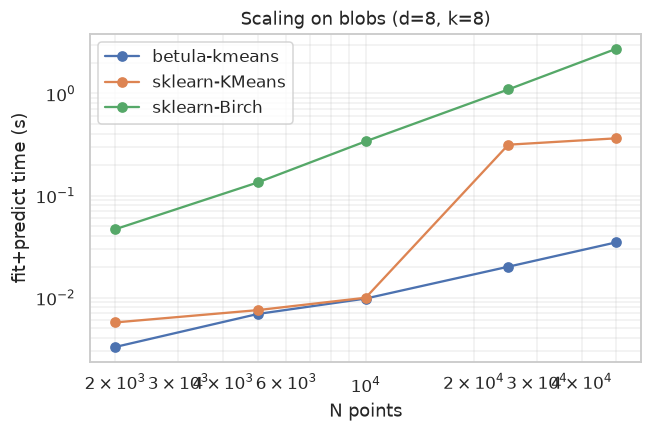

In [4]:
Ns = [2000, 5000, 10000, 25000, 50000]
rows = {"betula-kmeans": [], "sklearn-KMeans": [], "sklearn-Birch": []}
from sklearn.cluster import KMeans

for n in Ns:
    Xb, _ = make_blobs(n_samples=n, centers=8, n_features=8, cluster_std=1.0, random_state=0)
    Xb = np.ascontiguousarray(Xb, dtype=np.float64)
    for name, fn in [
        ("betula-kmeans", lambda X: betula_cluster.fit_predict(X, 8, feature="diagonal", method="kmeans")),
        ("sklearn-KMeans", lambda X: KMeans(8, n_init=4, random_state=0).fit_predict(X)),
        ("sklearn-Birch", lambda X: Birch(n_clusters=8, threshold=8 ** 0.5 * 0.5).fit_predict(X)),
    ]:
        t0 = time.perf_counter()
        fn(Xb)
        rows[name].append(time.perf_counter() - t0)

plt.figure(figsize=(6, 4))
for name, ts in rows.items():
    plt.loglog(Ns, ts, "o-", label=name)
plt.xlabel("N points")
plt.ylabel("fit+predict time (s)")
plt.title("Scaling on blobs (d=8, k=8)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Memory — the headline

betula's CF-tree is bounded by `max_leaves`; classic Birch's subclusters explode in high-d. Peak
RSS at **100 000 × 10-d** (isolated-subprocess measurement from `bench/RESULTS.md`):

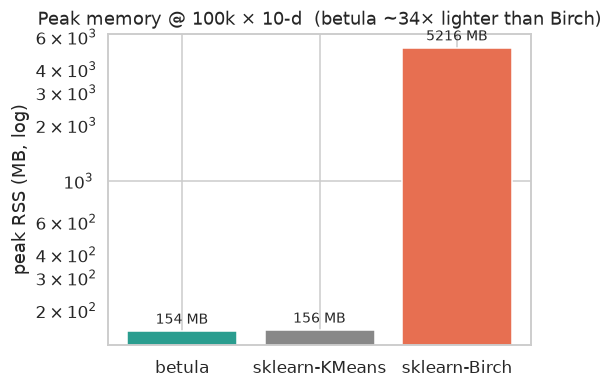

In [5]:
plt.figure(figsize=(5, 3.6))
bars = {"betula": 154, "sklearn-KMeans": 156, "sklearn-Birch": 5216}
plt.bar(bars.keys(), bars.values(), color=["#2a9d8f", "#888", "#e76f51"])
plt.ylabel("peak RSS (MB, log)")
plt.yscale("log")
for i, (k, v) in enumerate(bars.items()):
    plt.text(i, v * 1.1, f"{v} MB", ha="center", fontsize=9)
plt.title("Peak memory @ 100k × 10-d  (betula ~34× lighter than Birch)")
plt.tight_layout()
plt.show()